# Bayesian optimization for chemical reactions with BayBE

BayBE is s a general-purpose toolbox for Bayesian Design of (chemical) experiments, developed by the pharmaceutical company Merck: https://emdgroup.github.io/baybe/stable/. Here, we will first introduce the basic functionality of this software package by focusing on a "dummy" experiment, after which you will be able to experiment on a real-world high-throughput experimentation dataset of Suzuki cross-coupling reactions.



In [7]:
%load_ext autoreload
%autoreload 0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
!curl -O https://raw.githubusercontent.com/chimie-paristech-CTM/PSL_notebooks/main/bayesian_optimization/shields_dataset.xlsx

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 88465  100 88465    0     0  1633k      0 --:--:-- --:--:-- --:--:-- 1763k


In [9]:
!pip install scikit-learn numpy==1.26 matplotlib scipy openpyxl==3.1.5 seaborn
!pip install baybe[chem,simulation]==0.13.1 

In [10]:
from baybe import Campaign
from baybe.objectives import SingleTargetObjective
from baybe.parameters import NumericalDiscreteParameter, SubstanceParameter
from baybe.recommenders import (
    BotorchRecommender,
    RandomRecommender,
    TwoPhaseMetaRecommender,
)

import pandas as pd

from baybe.acquisition import qUpperConfidenceBound

from baybe.searchspace import SearchSpace
from baybe.surrogates import GaussianProcessSurrogate
from baybe.surrogates.base import Surrogate
from baybe.targets import NumericalTarget
from baybe.utils.basic import get_subclasses
from baybe.utils.dataframe import add_fake_measurements
from baybe.constraints import ContinuousLinearConstraint, DiscreteCustomConstraint

## Setting up the search space

We focus here on an imaginary direct arylation reaction, where we are able to fine tune solvent, ligand, base as well as concentration and temperature. The first three variables are categorical, so we need to enumerate all the options for each of these variables first and foremost.

In [11]:
dict_solvent = {
    "DMAc": r"CC(N(C)C)=O",
    "Butyornitrile": r"CCCC#N",
    "Butyl Ester": r"CCCCOC(C)=O",
    "p-Xylene": r"CC1=CC=C(C)C=C1",
}

dict_base = {
    "Potassium acetate": r"O=C([O-])C.[K+]",
    "Potassium pivalate": r"O=C([O-])C(C)(C)C.[K+]",
    "Cesium acetate": r"O=C([O-])C.[Cs+]",
    "Cesium pivalate": r"O=C([O-])C(C)(C)C.[Cs+]",
}

dict_ligand = {
    "BrettPhos": r"CC(C)C1=CC(C(C)C)=C(C(C(C)C)=C1)C2=C(P(C3CCCCC3)C4CCCCC4)C(OC)=CC=C2OC",
    "Di-tert-butylphenylphosphine": r"CC(C)(C)P(C1=CC=CC=C1)C(C)(C)C",
    "(t-Bu)PhCPhos": r"CN(C)C1=CC=CC(N(C)C)=C1C2=CC=CC=C2P(C(C)(C)C)C3=CC=CC=C3",
}

Next, we need to define a numerical representation for each of the substances, i.e., we need to assign a vector to each compound. This will enable us to define a "distance" between individual compounds, and thus quantify the covariance between pairs of compounds.

Here, we will work with a MORDRED encoding (the default in BayBE). Mordred is a Python library used to compute molecular descriptors from chemical structures. A Mordred encoding of chemical compounds refers to the set of molecular descriptors generated using this library. These descriptors numerically represent various structural, topological, electronic, and physicochemical properties of a molecule, making them useful for machine learning, cheminformatics, and QSAR (Quantitative Structure-Activity Relationship) studies.

In [12]:
solvent = SubstanceParameter("Solvent", data=dict_solvent, encoding="MORDRED")
base = SubstanceParameter("Base", data=dict_base, encoding="MORDRED")
ligand = SubstanceParameter("Ligand", data=dict_ligand, encoding="MORDRED")

Next, we proceed by defining the numerical variables.

In [13]:
temperature = NumericalDiscreteParameter(
    "Temperature", values=[90, 105, 120], tolerance=2
)
concentration = NumericalDiscreteParameter(
    "Concentration", values=[0.057, 0.1, 0.153], tolerance=0.005
)

BayBE lets you mirror real-world experimental rules by **filtering** or **restricting** the space of possible experiments before optimization even begins. In practice, you define:


Continuous constraints
- Carve out valid regions of your numeric parameters.  
- **Example:** Forcing mixture components to sum to 1.0, or limiting how many reagents can be “active” at once (e.g. at least one and at most two non-zero concentrations).  
- Ensures the optimizer only proposes concentration or temperature combinations that actually make sense in the lab (e.g. no “negative” or impossible sums).

Discrete constraints
- Remove invalid categorical or grid-based combinations.  
- **Examples:**  
  - Ban known incompatibilities (e.g. a certain catalyst with high temperatures)  
  - Gate parameters behind an “on/off” switch (extra knobs only appear when the switch is “on”)  
  - Prevent duplicate selections across multiple reagent slots  
- Under the hood, BayBE enumerates all candidate combinations and then **filters** them against these rules so your optimizer never even sees the disallowed entries.


By layering these continuous and discrete filters—optionally tied to simple logical conditions —you precisely reflect your lab’s limitations (mixture fractions summing to unity, reagent–temperature incompatibilities, conditional parameters, etc.) while still letting the Bayesian engine focus on finding the best experiments.


In [14]:
# your solvent → boiling point map (°C)
dict_boiling_points = {
    "DMAc": 165.0,
    "Butyornitrile": 117.6,
    "Butyl Ester": 126.1,
    "p-Xylene": 138.35 
}

T_margin = 5.0  # °C safety margin

# Create a function which verifies if the expirement temperature meets the boiling point criteria
def solvent_bp_ok(df: pd.DataFrame) -> pd.Series:
    bp_series = df["Solvent"].map(dict_boiling_points)
    return df["Temperature"] <= (bp_series - T_margin)

# wrap it in a BayBE custom discrete‐space constraint
constraint_bp = DiscreteCustomConstraint(
    parameters=["Solvent", "Temperature"],
    validator=solvent_bp_ok
)

Finally, we can set up the search space.

In [15]:
parameters = [solvent, base, ligand, temperature, concentration]

searchspace = SearchSpace.from_product(parameters=parameters)

## Defining the objective

In this example, we maximize the yield of a reaction and define a corresponding objective.

In [16]:
objective = SingleTargetObjective(target=NumericalTarget(name="yield", mode="MAX"))

## Setting up the Bayesian Optimization campaign

Now, we can set up our Bayesian Optimization campaign. Initially, we have no data about the reaction, so we cannot apply a surrogate model to generate a prior, which can inform us about which experiment to prioritize. 

As such, some initial measurements will need to be made. We will start by performing random experiments.

In [17]:
INITIAL_RECOMMENDER = RandomRecommender()

Once a couple of random experiments will have been performed, we will be able to set up the surrogate model and use an acquisition function to identify experiments to perform next. We will set this up below.

In [18]:
SURROGATE_MODEL = GaussianProcessSurrogate() # We will use Gaussian Processes as the surrogate to construct the prior

ACQ_FUNCTION = "qUCB" # upper confidence bound with a default beta of 0.2 is selected here for simplicity

Now that we have defined all the settings for the initial recommender as well as the "advanced" recommender, we can finalize the set-up of the campaign.

In [19]:
# TwoPhaseMetaRecommender, because we have two phases in the recommendations, 
# and the search space contains both discrete and continuous variables (i.e., it is a "meta" search space).

recommender = TwoPhaseMetaRecommender(
    initial_recommender=INITIAL_RECOMMENDER,
    recommender=BotorchRecommender(
        surrogate_model=SURROGATE_MODEL, acquisition_function=ACQ_FUNCTION
    ), switch_after=4
)

We can now take a closer look at the Recommender object we have created.

In [20]:
print(recommender)

TwoPhaseMetaRecommender
   Initial recommender
      RandomRecommender
         Compatibility: SearchSpaceType.HYBRID
   Recommender
      BotorchRecommender
         Surrogate
            GaussianProcessSurrogate
               Supports Transfer Learning: True
               Kernel factory: DefaultKernelFactory()
         Acquisition function: qUpperConfidenceBound(beta=0.2)
         Compatibility: SearchSpaceType.HYBRID
         Sequential continuous: True
         Hybrid sampler: None
         Sampling percentage: 1.0
   Switch after: 4
   Remain switched: False
   Has switched: False


Let's now change the beta for the UCB acquisition function.

In [21]:
ACQ_FUNCTON = qUpperConfidenceBound(beta=1.0)

recommender = TwoPhaseMetaRecommender(
    initial_recommender=INITIAL_RECOMMENDER,
    recommender=BotorchRecommender(
        surrogate_model=SURROGATE_MODEL, acquisition_function=ACQ_FUNCTON
    ), switch_after=4
)

QUESTION: What is the role of the beta parameter in the UpperConfidenceBound acquisition function? What will happen if I reduce its value to 0.1?

Finally, we can set up the BO campaign.

In [22]:
campaign = Campaign(
    searchspace=searchspace,
    recommender=recommender,
    objective=objective,
)

## Running the campaign

We can now run the campaign straightforwardly. We start by getting initial recommendations from the model.

In [23]:
recommendation = campaign.recommend(batch_size=4)
print("\n\nRecommended experiments: ")
print(recommendation)



Recommended experiments: 
         Solvent             Base                        Ligand  Temperature  \
23   Butyl Ester   Cesium acetate  Di-tert-butylphenylphosphine        105.0   
46   Butyl Ester  Cesium pivalate  Di-tert-butylphenylphosphine         90.0   
246         DMAc  Cesium pivalate                 (t-Bu)PhCPhos        105.0   
361     p-Xylene  Cesium pivalate                     BrettPhos         90.0   

     Concentration  
23           0.153  
46           0.100  
246          0.057  
361          0.100  


Since we are not going to run the experiments in reality, we are going to feed "fake" measurements back to the model.

In [24]:
add_fake_measurements(recommendation, campaign.targets)
print("\n\nRecommended experiments with fake measured values: ")
print(recommendation)



Recommended experiments with fake measured values: 
         Solvent             Base                        Ligand  Temperature  \
23   Butyl Ester   Cesium acetate  Di-tert-butylphenylphosphine        105.0   
46   Butyl Ester  Cesium pivalate  Di-tert-butylphenylphosphine         90.0   
246         DMAc  Cesium pivalate                 (t-Bu)PhCPhos        105.0   
361     p-Xylene  Cesium pivalate                     BrettPhos         90.0   

     Concentration      yield  
23           0.153  11.331215  
46           0.100  29.020393  
246          0.057  26.939731  
361          0.100   1.522116  


In [25]:
campaign.add_measurements(recommendation)

In [26]:
# TODO: Continue the campagin by adding some additional experiments.
for i in range(10):
    print(f'round {i}...')
    recommendation = campaign.recommend(batch_size=2)
    print("\n\nRecommended experiments: ")
    add_fake_measurements(recommendation, campaign.targets)
    print("\n\nRecommended experiments with fake measured values: ")
    print(recommendation)   


round 0...


Recommended experiments: 


Recommended experiments with fake measured values: 
           Solvent             Base                        Ligand  \
index                                                               
45     Butyl Ester  Cesium pivalate  Di-tert-butylphenylphosphine   
47     Butyl Ester  Cesium pivalate  Di-tert-butylphenylphosphine   

       Temperature  Concentration      yield  
index                                         
45            90.0          0.057  21.027958  
47            90.0          0.153   0.007191  
round 1...


Recommended experiments: 


Recommended experiments with fake measured values: 
           Solvent             Base                        Ligand  \
index                                                               
45     Butyl Ester  Cesium pivalate  Di-tert-butylphenylphosphine   
47     Butyl Ester  Cesium pivalate  Di-tert-butylphenylphosphine   

       Temperature  Concentration      yield  
index                    

/opt/miniconda3/envs/baybe-py312/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


# Bayesian optimization of the reaction yield for a real-world dataset

In [27]:
import baybe

import os
os.environ['BAYBE_CACHE_DIR']='' # turn descriptor caching off
from baybe.utils.random import set_random_seed
set_random_seed(1337)

# Load in the dataset 
The problem we study here, corresponds to the chemical reaction yield optimization from [Shields, B.J., Stevens et al. Nature 590, 89–96 (2021)](https://doi.org/10.1038/s41586-021-03213-y).
![reaction](https://raw.githubusercontent.com/emdgroup/baybe-ac24-workshop/main/files/reaction.png)

The parameters screened are:
- Solvent
- Base
- Ligand
- Concentration (of the solvent)
- Temperature

There is one target that should be maximized:
- yield

We will load in the high-throughput dataset as a lookup table, so that we do not need to run the experiments ourselves. Instead, we can look up the experimental yield for any combination of reaction parameters.

In [28]:
lookup = pd.read_excel('shields_dataset.xlsx', index_col=0)
F_BEST = lookup['yield'].max()
lookup.head()

,Base_SMILES,Ligand_SMILES,Solvent_SMILES,Concentration,Temp_C,yield,Base,Ligand,Solvent
entry,,,,,,,,,
0,O=C([O-])C.[K+],CC(C)C1=CC(C(C)C)=C(C(C(C)C)=C1)C2=C(P(C3CCCCC...,CC(N(C)C)=O,0.1,105,5.47,Potassium acetate,BrettPhos,DMAc
1,O=C([O-])C.[K+],CC(C)(C)P(C1=CC=CC=C1)C(C)(C)C,CC(N(C)C)=O,0.1,105,0.00,Potassium acetate,Di-tert-butylphenylphosphine,DMAc
2,O=C([O-])C.[K+],CN(C)C1=CC=CC(N(C)C)=C1C2=CC=CC=C2P(C(C)(C)C)C...,CC(N(C)C)=O,0.1,105,78.95,Potassium acetate,(t-Bu)PhCPhos,DMAc
3,O=C([O-])C.[K+],P(C1CCCCC1)(C2CCCCC2)C3CCCCC3,CC(N(C)C)=O,0.1,105,7.26,Potassium acetate,Tricyclohexylphosphine,DMAc
4,O=C([O-])C.[K+],P(C1=CC=CC=C1)(C2=CC=CC=C2)C3=CC=CC=C3,CC(N(C)C)=O,0.1,105,28.15,Potassium acetate,PPh3,DMAc


### SMILES
Note that the structure of the molecules is represented by SMILES strings.

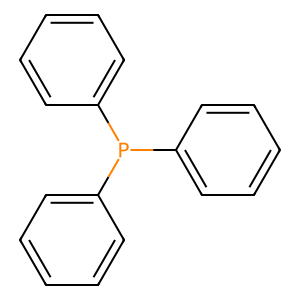

In [29]:
from rdkit import Chem
from rdkit.Chem import Draw

ligand = Chem.MolFromSmiles('P(C1=CC=CC=C1)(C2=CC=CC=C2)C3=CC=CC=C3') #PPh3
Draw.MolToImage(ligand)

EXERCISE: Visualize also the first ligand and solvent SMILES encountered in the dataset

### Data Exploration
It is important to realize that optimizing the yield essentially corresponds to solving a needle-in-a-haystack problem: the data distribution is very much skewed towards low yields in the lookup dataset.

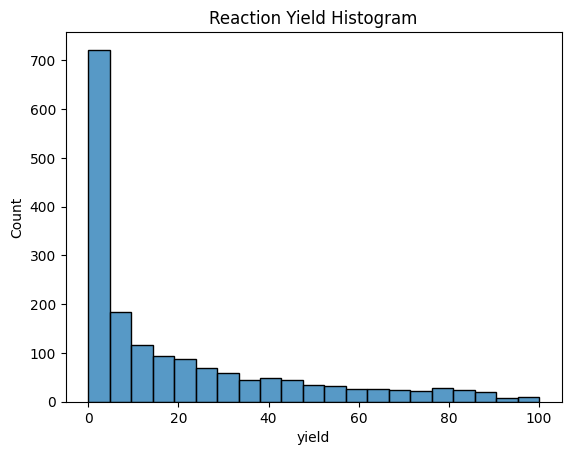

In [30]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.histplot(data = lookup, x = 'yield', edgecolor = 'black');
plt.title('Reaction Yield Histogram');

### Setting up the search space

Just as in the introductory example, we first need to setup the search space. Instead of manually defining this here, we will extract it from the lookup dataset.

In [31]:
solvent_data = dict(sorted(set(zip(lookup.Solvent, lookup.Solvent_SMILES))))
solvent_data

{'Butyl Ester': 'CCCCOC(C)=O',
 'Butyornitrile': 'CCCC#N',
 'DMAc': 'CC(N(C)C)=O',
 'p-Xylene': 'CC1=CC=C(C)C=C1'}

In [32]:
base_data = dict(sorted(set(zip(lookup.Base, lookup.Base_SMILES))))
base_data

{'Cesium acetate': 'O=C([O-])C.[Cs+]',
 'Cesium pivalate': 'O=C([O-])C(C)(C)C.[Cs+]',
 'Potassium acetate': 'O=C([O-])C.[K+]',
 'Potassium pivalate': 'O=C([O-])C(C)(C)C.[K+]'}

In [33]:
ligand_data = dict(sorted(set(zip( lookup.Ligand, lookup.Ligand_SMILES))))
ligand_data

{'(t-Bu)PhCPhos': 'CN(C)C1=CC=CC(N(C)C)=C1C2=CC=CC=C2P(C(C)(C)C)C3=CC=CC=C3',
 '1268824-69-6': 'CC(OC1=C(P(C2CCCCC2)C3CCCCC3)C(OC(C)C)=CC=C1)C',
 'BrettPhos': 'CC(C)C1=CC(C(C)C)=C(C(C(C)C)=C1)C2=C(P(C3CCCCC3)C4CCCCC4)C(OC)=CC=C2OC',
 'Di-tert-butylphenylphosphine': 'CC(C)(C)P(C1=CC=CC=C1)C(C)(C)C',
 'JackiePhos': 'FC(F)(F)C1=CC(P(C2=C(C3=C(C(C)C)C=C(C(C)C)C=C3C(C)C)C(OC)=CC=C2OC)C4=CC(C(F)(F)F)=CC(C(F)(F)F)=C4)=CC(C(F)(F)F)=C1',
 'Me2PPh': 'CP(C)C1=CC=CC=C1',
 'Methyldiphenylphosphine': 'CP(C1=CC=CC=C1)C2=CC=CC=C2',
 'P(2-furyl)3': 'P(C1=CC=CO1)(C2=CC=CO2)C3=CC=CO3',
 'PPh3': 'P(C1=CC=CC=C1)(C2=CC=CC=C2)C3=CC=CC=C3',
 'SCHEMBL15068049': 'C[C@]1(O2)O[C@](C[C@]2(C)P3C4=CC=CC=C4)(C)O[C@]3(C)C1',
 'Tricyclohexylphosphine': 'P(C1CCCCC1)(C2CCCCC2)C3CCCCC3',
 'XPhos': 'CC(C1=C(C2=CC=CC=C2P(C3CCCCC3)C4CCCCC4)C(C(C)C)=CC(C(C)C)=C1)C'}

In [34]:
temperature_values = set(lookup.Temp_C)
temperature_values

{90, 105, 120}

In [35]:
concentration_values = set(lookup.Concentration)
concentration_values

{0.057, 0.1, 0.153}

## Substance featurizations: One hot encoding

To demonstrate how featurization of substances impact the speed at which the model is able to locate good reaction conditions to maximize the yield, we will start by considering a One Hot Encoding (OHE) featurization, i.e., every individual solvent, base and ligand is assigned a separate dimension in the search space (with only two possible values: 0 if the substance is not used in this experiment, and 1 if it is). Temperature and concentration are encoded as numerical discrete parameters.

In [36]:
from baybe.parameters import CategoricalParameter, NumericalDiscreteParameter

p_solvent_ohe = CategoricalParameter(name = "Solvent",
                                    values = solvent_data.keys(),
                                    encoding = 'OHE')
p_base_ohe = CategoricalParameter(name = "Base",
                                    values = base_data.keys(),
                                    encoding = 'OHE')
p_ligand_ohe = CategoricalParameter(name = "Ligand",
                                    values = ligand_data.keys(),
                                    encoding = 'OHE') # INT or OHE


with pd.option_context('display.max_columns', 5):
    display(p_ligand_ohe.comp_df.head())

,Ligand_(t-Bu)PhCPhos,Ligand_1268824-69-6,...,Ligand_Tricyclohexylphosphine,Ligand_XPhos
(t-Bu)PhCPhos,1.0,0.0,...,0.0,0.0
1268824-69-6,0.0,1.0,...,0.0,0.0
BrettPhos,0.0,0.0,...,0.0,0.0
Di-tert-butylphenylphosphine,0.0,0.0,...,0.0,0.0
JackiePhos,0.0,0.0,...,0.0,0.0


In [37]:
# Discrete numerical parameters
p_temp = NumericalDiscreteParameter(name = "Temp_C", values = temperature_values)
p_concentration = NumericalDiscreteParameter(name = "Concentration", values = concentration_values)

ohe_parameters = [
    p_solvent_ohe,
    p_base_ohe, 
    p_ligand_ohe,
    p_concentration, 
    p_temp
]

In [38]:
from baybe.searchspace import SearchSpace

searchspace_ohe = SearchSpace.from_product(parameters=ohe_parameters)

EXERCISE: Set up the target and the objective

In [39]:
objective2 = SingleTargetObjective(target=NumericalTarget(name="yield", mode="MAX"))

Let's now set up a campaign; we will not specify the recommender this time, but simply adopt the default settings from BayBE (you can take a look through the scource code if you want to know the details).

In [40]:
from baybe.campaign import Campaign

ohe_campaign = Campaign(objective = objective2,
                    searchspace = searchspace_ohe)

In [41]:
from baybe.simulation import simulate_scenarios

MC_RUNS = 10 # this will take fairly long on typical free-of-charge cloud compute
NUMBER_ITERATIONS = 16
BATCH_SIZE = 2

# Run the utility for backtesting
results_ohe = simulate_scenarios(
    {'OHE': ohe_campaign},
    lookup, # the initial dataframe with the experimental results is our lookup
    batch_size = BATCH_SIZE, # how many experiments to perform in one batch
    n_doe_iterations = NUMBER_ITERATIONS, # how many batches to select successively
    n_mc_iterations = MC_RUNS, # number of Monte Carlo iterations -> this corresponds to the number of times we take a new random starting point 
                                # and run the full campaign from scratch (to get a statistically) meaningful sense about the merit of the featurization approach
)
results_ohe.head()

100%|##########| 10/10 [01:42<00:00, 10.29s/it]


,Scenario,Monte_Carlo_Run,Iteration,Num_Experiments,yield_Measurements,yield_IterBest,yield_CumBest
0,OHE,0,0,2,"[0.0, 12.98]",12.98,12.98
1,OHE,0,1,4,"[38.15, 3.04]",38.15,38.15
2,OHE,0,2,6,"[49.17, 72.45]",72.45,72.45
3,OHE,0,3,8,"[61.33, 54.83]",61.33,72.45
4,OHE,0,4,10,"[11.07, 14.06]",14.06,72.45


To visualize the campaign, we will define an auxiliary function.

In [42]:
PLOTARGS = {
    'linestyle': 'solid',
    'marker': 'o',
    'markersize': 6, 
    'markeredgecolor': 'none'
}
FIGSIZE = (11,6)

def plot_campaign(results):
    results.rename(columns = {"Scenario": "Ligand Encoding"}, inplace = True)
    sns.lineplot(data = results, 
             x = "Num_Experiments", 
             y = "yield_CumBest", 
             hue = "Ligand Encoding",
             **PLOTARGS)

    plt.axhline(y = F_BEST, color = 'red', linestyle = '--', label = 'Best Possible')
    plt.gcf().set_size_inches(FIGSIZE)
    plt.gca().set_ylim(plt.gca().get_ylim()[0], F_BEST+5)
    plt.title('Influence of the Ligand Substance Encoding'); 

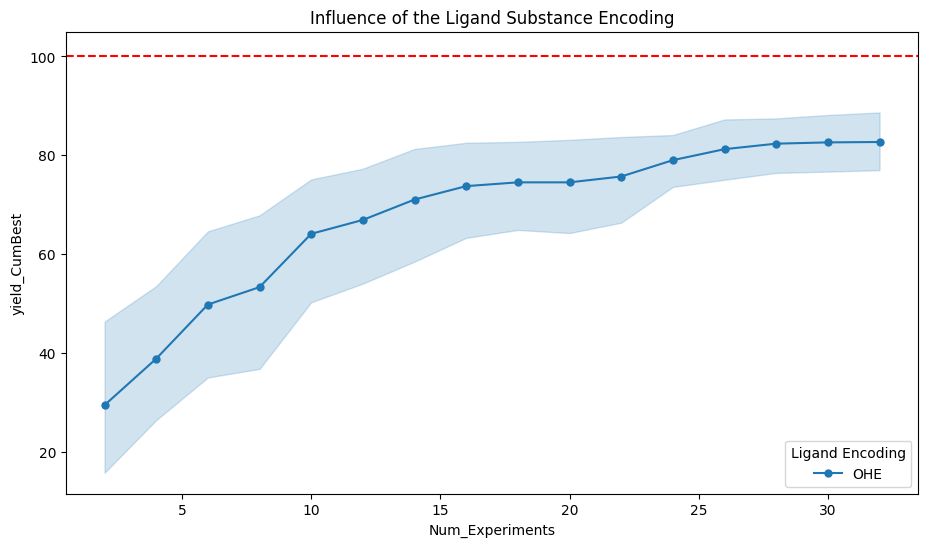

In [43]:
plot_campaign(results_ohe)

In the plot above, you can see visually see how throughout the campaign, we gradually manage to increase the yield (the blue line is the average best yield recorded so far after N experiments across the 10 Monte Carlo campaign simulations; the shaded area provides the standard deviation).

Let's now compare this Bayesian Optimization campaign to a random sampling, i.e., we randomly select points in the search space to evaluate, instead of using an acquisition function.

## Substance featurizations: Mordred encoding

In [44]:
from baybe.recommenders import RandomRecommender

random_campaign = Campaign(objective = objective,
                       searchspace = searchspace_ohe,
                       recommender = RandomRecommender())

In [45]:
# Run the utility for backtesting
results_random = simulate_scenarios(
    {'random': random_campaign},
    lookup, # the initial dataframe with the experimental results is our lookup
    batch_size = BATCH_SIZE,
    n_doe_iterations = NUMBER_ITERATIONS,
    n_mc_iterations = MC_RUNS,
)
results_random.head()

  0%|          | 0/10 [00:00<?, ?it/s]/opt/miniconda3/envs/baybe-py312/lib/python3.12/site-packages/baybe/recommenders/pure/nonpredictive/base.py:46: UnusedObjectWarning: 'recommend' was called with a an explicit objective but 'RandomRecommender' does not consider any objectives, meaning that the argument is ignored.
  warnings.warn(
/opt/miniconda3/envs/baybe-py312/lib/python3.12/site-packages/baybe/recommenders/pure/nonpredictive/base.py:39: UnusedObjectWarning: 'recommend' was called with a non-empty set of measurements but 'RandomRecommender' does not utilize any training data, meaning that the argument is ignored.
  warnings.warn(
/opt/miniconda3/envs/baybe-py312/lib/python3.12/site-packages/baybe/recommenders/pure/nonpredictive/base.py:46: UnusedObjectWarning: 'recommend' was called with a an explicit objective but 'RandomRecommender' does not consider any objectives, meaning that the argument is ignored.
  warnings.warn(
/opt/miniconda3/envs/baybe-py312/lib/python3.12/site-packa

,Scenario,Monte_Carlo_Run,Iteration,Num_Experiments,yield_Measurements,yield_IterBest,yield_CumBest
0,random,0,0,2,"[0.0, 4.06]",4.06,4.06
1,random,0,1,4,"[25.35, 18.59]",25.35,25.35
2,random,0,2,6,"[20.03, 55.41]",55.41,55.41
3,random,0,3,8,"[0.01, 12.44]",12.44,55.41
4,random,0,4,10,"[0.0, 65.32]",65.32,65.32


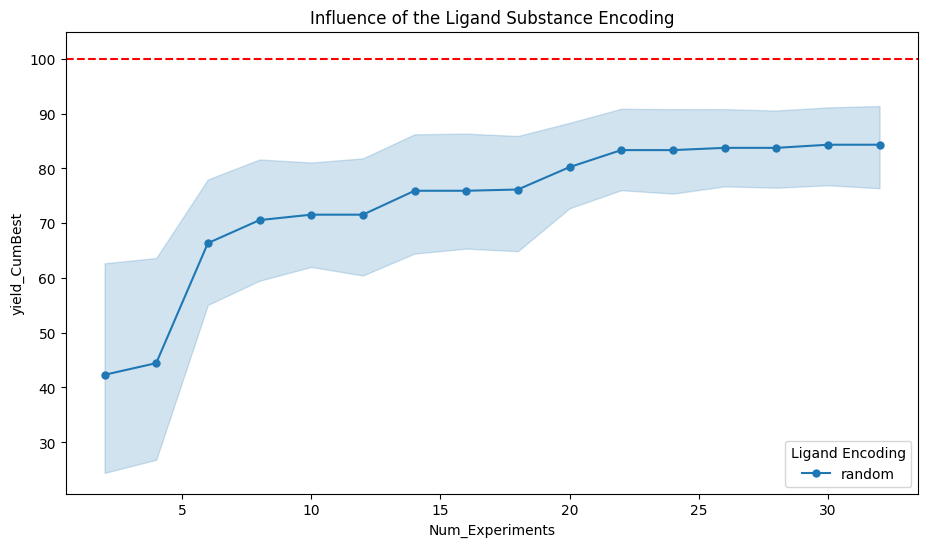

In [46]:
plot_campaign(results_random)

This hardly seems any better than when we used the one-hot encoding representation of the compounds!

Let us now consider instead of a one-hot encoding a more chemically meaningful encoding that enables the establishment of "similarity" between substances. We will specifically focus on the MORDRED representation, but others are also available in BayBE.

In [47]:
p_solvent_mordred = SubstanceParameter(name = "Solvent",
                                    data = solvent_data,
                                    encoding = 'MORDRED')
p_base_mordred = SubstanceParameter(name = "Base",
                                    data = base_data,
                                    encoding = 'MORDRED')
p_ligand_mordred = SubstanceParameter(name = "Ligand",
                                    data = ligand_data,
                                    encoding = 'MORDRED')


mordred_parameters = [
    p_solvent_mordred,
    p_base_mordred, 
    p_ligand_mordred,
    p_concentration, 
    p_temp
]

searchspace_mordred = SearchSpace.from_product(parameters=mordred_parameters)

with pd.option_context('display.max_columns', 5):
    display(p_ligand_mordred.comp_df.head())

mordred_campaign = Campaign(objective = objective,
                    searchspace = searchspace_mordred)

# Run the utility for backtesting
results_mordred = simulate_scenarios(
    {'mordred': mordred_campaign},
    lookup, # the initial dataframe with the experimental results is our lookup
    batch_size = BATCH_SIZE, # how many experiments to perform in one batch
    n_doe_iterations = NUMBER_ITERATIONS, # how many batches to select successively
    n_mc_iterations = MC_RUNS, # number of Monte Carlo iterations -> this corresponds to the number of times we take a new random starting point 
                                # and run the full campaign from scratch (to get a statistically) meaningful sense about the merit of the featurization approach
)
results_mordred.head()

,Ligand_MORDRED_ABC,Ligand_MORDRED_SpMax_A,...,Ligand_MORDRED_JGI7,Ligand_MORDRED_TopoShapeIndex
(t-Bu)PhCPhos,22.449495,2.507279,...,0.020557,1.000000
1268824-69-6,20.741455,2.468664,...,0.015783,0.800000
BrettPhos,29.162436,2.555080,...,0.014660,1.000000
Di-tert-butylphenylphosphine,11.396454,2.429653,...,0.000000,1.000000
JackiePhos,42.136730,2.572820,...,0.017747,0.857143


100%|##########| 10/10 [02:02<00:00, 12.28s/it]


,Scenario,Monte_Carlo_Run,Iteration,Num_Experiments,yield_Measurements,yield_IterBest,yield_CumBest
0,mordred,0,0,2,"[2.59, 30.17]",30.17,30.17
1,mordred,0,1,4,"[63.2, 13.13]",63.20,63.20
2,mordred,0,2,6,"[52.23, 99.22]",99.22,99.22
3,mordred,0,3,8,"[95.48, 92.19]",95.48,99.22
4,mordred,0,4,10,"[98.38, 43.84]",98.38,99.22


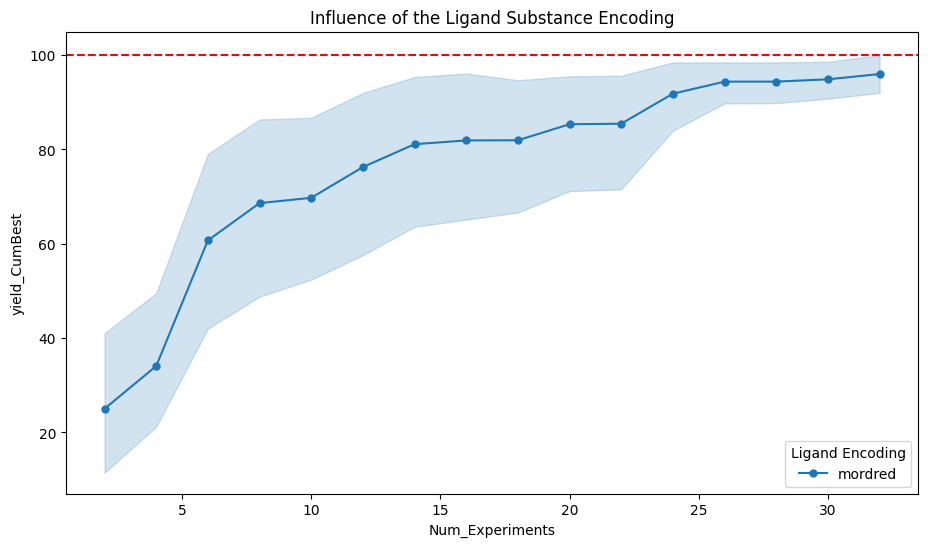

In [48]:
plot_campaign(results_mordred)

This looks a lot better already! Let's now plot all 3 types of campaigns together in one plot.

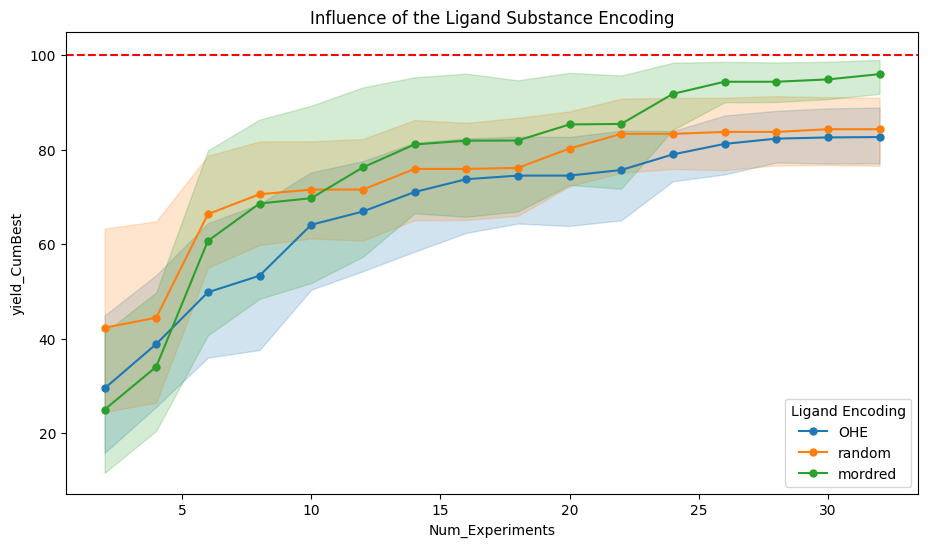

In [49]:
results_combined = pd.concat([results_ohe, results_random, results_mordred], ignore_index=True)
plot_campaign(results_combined)

Clearly, the choice of encoding matter: the Mordred campaign found the optimal yield rapidly, and clearly outperforms the other approaches tried out.